<div style="background:linear-gradient(135deg,#4a148c,#6a1b9a,#7b1fa2);padding:36px 28px;border-radius:14px;color:#fff;text-align:center">
<h1 style="margin:0;font-size:2.2em">⚗️ Notebook 4 — Reactor Batch</h1>
<h2 style="margin:10px 0 4px;font-weight:300;opacity:.92">Cinética Experimental · Diseño por Lotes · Seguridad Térmica</h2>
<p style="margin:4px 0 0;opacity:.85">Fogler Capítulos 4, 7 y 9 · 740484 Diseño de Reactores · Universidad del Valle</p>
</div>

---

## 🎯 Objetivos

1. Derivar la ecuación de diseño del reactor batch y calcular el tiempo de reacción.
2. Determinar parámetros cinéticos por los **métodos integral y diferencial** (Fogler §7.2).
3. Diseñar la operación por lotes: número de lotes, tiempo de ciclo, productividad.
4. Simular el batch no isotérmico e identificar $t_{mr}$ para análisis de seguridad.
5. Comparar el tamaño relativo de CSTR, PFR y Batch para la misma cinética.

## 📚 Mapa de referencias — Fogler 4ª Ed.

| Tema | Sección | Ecuación |
|------|---------|----------|
| Ecuación de diseño batch | §4.1, Ec. 4-5 | $t = C_{A0}\int_0^X dX/(-r_A)$ |
| Soluciones analíticas | §4.2 | Tabla por orden n |
| Método diferencial | §7.2.1 | $\ln(-r_A) = \ln k + n\ln C_A$ |
| Método integral | §7.2.2 | Linealización según orden supuesto |
| Batch no isotérmico | §9.1, Ec. 9-9 | ODE $dT/dt$ acoplada |
| Análisis $t_{mr}$ | §9.2 | $d(-r_A)/dt = 0$ |

## 🏭 Contexto industrial del reactor batch

El reactor batch domina en:

- **Industria farmacéutica**: síntesis multietapa de APIs (Ingredientes Activos Farmacéuticos), flexibilidad de campaña.
- **Colorantes y pigmentos especiales**: pequeños volúmenes, alta variedad.
- **Enzimología y biotecnología**: fermentaciones discontinuas, producción de anticuerpos.
- **Polímeros de especialidad**: resinas epoxi, poliésteres insaturados, poliuretanos de alto valor.
- **Explosivos e ingredientes energéticos**: por razones de seguridad (aislamiento de lotes).

La pregunta de diseño central es siempre: **¿cuántos litros ocupa reactor, cuántos lotes por día, a qué conversión?**


In [11]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch
from matplotlib.patheffects import withStroke
from scipy.integrate import odeint, cumulative_trapezoid
from ipywidgets import interact, FloatSlider, IntSlider
import warnings; warnings.filterwarnings('ignore')

plt.rcParams.update({
    'font.family':'DejaVu Sans','font.size':11,'axes.grid':True,
    'grid.alpha':0.28,'figure.dpi':110,'axes.titleweight':'bold',
    'lines.linewidth':2.3,'axes.titlesize':11.5,
    'axes.spines.top':False,'axes.spines.right':False,
})
print('Entorno listo.')


Entorno listo.


---
# 1. Derivación de la ecuación de diseño del batch — Fogler §4.1

## 1.1 Balance molar en el reactor batch

Para el reactor batch ideal (volumen constante, temperatura uniforme, sin flujos), el balance molar de la especie A es:

$$\frac{dN_A}{dt} = r_A\,V$$

Dado que $N_A = N_{A0}(1-X_A)$, diferenciando:

$$N_{A0}\frac{dX_A}{dt} = -r_A\,V$$

Para volumen constante: $C_{A0} = N_{A0}/V$, de modo que:

$$C_{A0}\frac{dX_A}{dt} = -r_A$$

Integrando:

$$\boxed{t = C_{A0}\int_0^{X_A}\frac{dX}{-r_A(X)}} \tag{4-5}$$

## 1.2 Equivalencia con el PFR

La ecuación del batch es **matemáticamente idéntica** a la del PFR con la sustitución $V \leftrightarrow t$ y $F_{A0} \leftrightarrow N_{A0}$:

$$\tau_\text{PFR} = \frac{V_\text{PFR}}{v_0} = C_{A0}\int_0^X\frac{dX}{-r_A} = t_\text{batch}$$

**Consecuencia**: para la misma cinética, concentración inicial y conversión deseada, el tiempo de reacción en batch es igual al tiempo espacial en el PFR equivalente.

## 1.3 Soluciones analíticas para cinéticas simples

| Orden n | Expresión cinética | Tiempo de reacción $t$ |
|---------|-------------------|------------------------|
| 0 | $-r_A = k$ | $t = C_{A0}X/k$ |
| **1** | $-r_A = kC_A$ | $t = \frac{1}{k}\ln\frac{1}{1-X}$ |
| **2** | $-r_A = kC_A^2$ | $t = \frac{X}{k\,C_{A0}(1-X)}$ |
| n | $-r_A = kC_A^n$ | Integración numérica |

## 1.4 Ciclo de operación y productividad

El tiempo total por lote incluye la reacción más las operaciones auxiliares:

$$t_\text{ciclo} = t_\text{rxn}(X) + \underbrace{t_\text{descarga+limpieza+carga}}_{t_\text{inactivo}}$$

**Productividad** [mol producto / unidad de tiempo]:

$$\mathcal{P} = \frac{C_{A0}\,X_A\,V_R}{t_\text{ciclo}} \qquad \text{[mol/min]}$$

**Diseño para máxima productividad**: existe una conversión óptima $X^*$ que maximiza $\mathcal{P}$ si $t_\text{rxn}(X)$ crece más rápido que linealmente (lo que ocurre siempre para n>0).


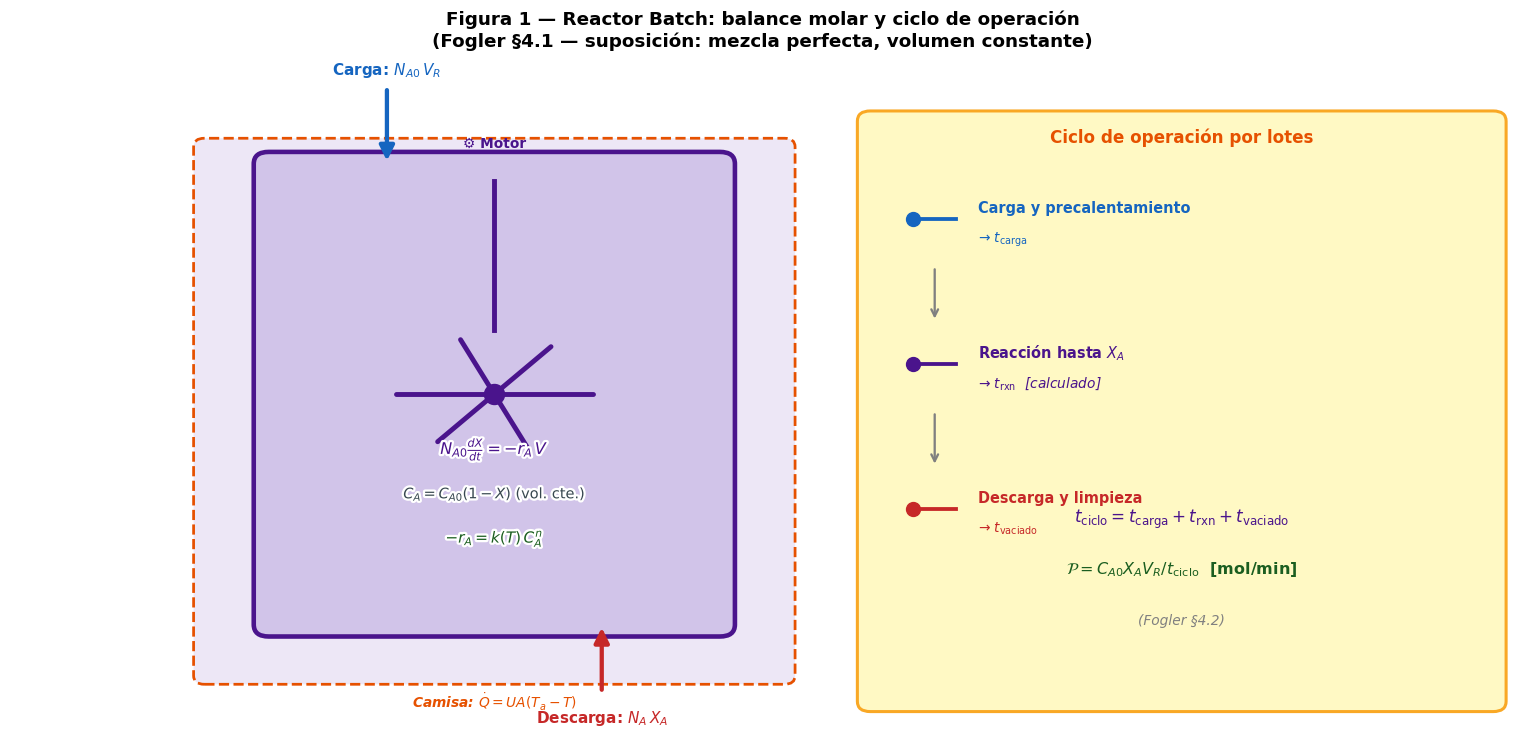

Figura 1 generada.


In [12]:
import os
# Figura 1 — Diagrama del reactor batch con ciclo de operación
pe = [withStroke(linewidth=3, foreground='white')]
fig, ax = plt.subplots(figsize=(14, 7))
ax.set_xlim(0, 14); ax.set_ylim(0, 8)
ax.axis('off'); ax.set_facecolor('#f5f0ff')

# Camisa
cam = FancyBboxPatch((1.8, 0.8), 5.4, 6.2,
                     boxstyle='round,pad=0.10',
                     facecolor='#EDE7F6', edgecolor='#E65100', lw=1.8, ls='--')
ax.add_patch(cam)
ax.text(4.5, 0.42, r'Camisa: $\dot{Q}=UA(T_a-T)$',
        ha='center', fontsize=9, color='#E65100', fontweight='bold', style='italic')

# Tanque
tank = FancyBboxPatch((2.4, 1.4), 4.2, 5.4,
                      boxstyle='round,pad=0.14',
                      facecolor='#D1C4E9', edgecolor='#4A148C', lw=3.0)
ax.add_patch(tank)

# Agitador
cx, cy = 4.5, 4.1
ax.plot([cx, cx], [cy+0.75, 6.6], color='#4A148C', lw=3.2)
for ang in [0, 55, 110, 180, 235, 290]:
    ax.plot([cx, cx+0.92*np.cos(np.radians(ang))],
            [cy, cy+0.68*np.sin(np.radians(ang))],
            color='#4A148C', lw=3.2, solid_capstyle='round')
ax.plot(cx, cy, 'o', color='#4A148C', ms=13, zorder=6)
ax.text(cx, 7.0, '⚙ Motor', ha='center', fontsize=9,
        color='#4A148C', fontweight='bold')

# Variables internas
ax.text(cx, 3.4, r'$N_{A0}\frac{dX}{dt} = -r_A\,V$',
        ha='center', fontsize=10.5, color='#4A148C', fontweight='bold', path_effects=pe)
ax.text(cx, 2.88, r'$C_A = C_{A0}(1-X)$ (vol. cte.)',
        ha='center', fontsize=9.5, color='#37474F', path_effects=pe)
ax.text(cx, 2.36, r'$-r_A = k(T)\,C_A^n$',
        ha='center', fontsize=10, color='#1B5E20', fontweight='bold', path_effects=pe)

# Carga (arriba)
ax.annotate('', xy=(3.5, 6.8), xytext=(3.5, 7.7),
            arrowprops=dict(arrowstyle='-|>', color='#1565C0', lw=2.8, mutation_scale=20))
ax.text(3.5, 7.85, r'Carga: $N_{A0}\,V_R$',
        ha='center', fontsize=10, color='#1565C0', fontweight='bold')

# Descarga (abajo)
ax.annotate('', xy=(5.5, 1.4), xytext=(5.5, 0.6),
            arrowprops=dict(arrowstyle='-|>', color='#C62828', lw=2.8, mutation_scale=20))
ax.text(5.5, 0.25, r'Descarga: $N_A\,X_A$',
        ha='center', fontsize=10, color='#C62828', fontweight='bold')

# Panel derecho — ciclo de operación
cycle = FancyBboxPatch((8.0, 0.5), 5.8, 6.8,
                       boxstyle='round,pad=0.12',
                       facecolor='#FFF9C4', edgecolor='#F9A825', lw=2.0)
ax.add_patch(cycle)
ax.text(10.9, 7.05, 'Ciclo de operación por lotes',
        ha='center', fontsize=11, fontweight='bold', color='#E65100')

pasos = [
    ('Carga y precalentamiento', '#1565C0', '→ $t_\mathrm{carga}$'),
    ('Reacción hasta $X_A$',     '#4A148C', '→ $t_\mathrm{rxn}$  [calculado]'),
    ('Descarga y limpieza',      '#C62828', '→ $t_\mathrm{vaciado}$'),
]
y_p = 6.15
for nombre, col, eq in pasos:
    ax.plot([8.4, 8.8], [y_p, y_p], '-', color=col, lw=2.5)
    ax.plot(8.4, y_p, 'o', color=col, ms=9)
    ax.text(9.0, y_p+0.08, nombre, fontsize=9.5, color=col, fontweight='bold')
    ax.text(9.0, y_p-0.26, eq, fontsize=9, color=col, style='italic')
    if y_p > 3.5:
        ax.annotate('', xy=(8.6, y_p-1.2), xytext=(8.6, y_p-0.55),
                    arrowprops=dict(arrowstyle='->', color='gray', lw=1.5))
    y_p -= 1.7

ax.text(10.9, 2.6, r'$t_\mathrm{ciclo} = t_\mathrm{carga}+t_\mathrm{rxn}+t_\mathrm{vaciado}$',
        ha='center', fontsize=11, color='#4A148C', fontweight='bold')
ax.text(10.9, 2.0, r'$\mathcal{P} = C_{A0}X_AV_R/t_\mathrm{ciclo}$  [mol/min]',
        ha='center', fontsize=10.5, color='#1B5E20', fontweight='bold')
ax.text(10.9, 1.4, '(Fogler §4.2)',
        ha='center', fontsize=9, color='gray', style='italic')

ax.set_title('Figura 1 — Reactor Batch: balance molar y ciclo de operación\n'
             '(Fogler §4.1 — suposición: mezcla perfecta, volumen constante)',
             fontsize=12, fontweight='bold', pad=10)
plt.tight_layout()

# Create the directory if it doesn't exist
os.makedirs('/home/claude/reactores', exist_ok=True)

plt.savefig('/home/claude/reactores/fig_nb4_batch.png', dpi=130,
            bbox_inches='tight', facecolor='#f5f0ff')
plt.show()
print('Figura 1 generada.')

---
# 2. Fogler Example 4-1: Diseño de reactor batch isotérmico

## 2.1 Enunciado (Fogler p. 131)

Producción de etilenglicol por hidrólisis del óxido de etileno:

$$\underbrace{(\text{CH}_2)_2\text{O}}_{\text{óxido de etileno (A)}} + \underbrace{\text{H}_2\text{O}}_{\text{exceso (B)}} \;\xrightarrow{\text{H}^+}\; \underbrace{\text{HOCH}_2\text{CH}_2\text{OH}}_{\text{etilenglicol (C)}}$$

**Datos:** $k = 0.311\;\text{min}^{-1}$ (25°C), $C_{A0} = 16.1\;\text{mol/dm}^3$, $X_{des} = 0.80$, $V_R = 1000\;\text{dm}^3$, $t_{vaciado} = 45\;\text{min}$.

## 2.2 Análisis de sensibilidad a la conversión

$$t_{rxn}(X) = \frac{\ln[1/(1-X)]}{k} = \frac{-\ln(1-X)}{0.311}$$

| X | $t_{rxn}$ [min] | $t_{ciclo}$ [min] | Prod/lote [kmol] | 𝒫 [mol/min] |
|---|-----------------|-------------------|-----------------|-------------|
| 0.50 | 2.23 | 47.23 | 8.05 | 170 |
| 0.80 | 5.17 | 50.17 | 12.88 | 257 |
| 0.90 | 7.41 | 52.41 | 14.49 | 276 |
| 0.95 | 9.41 | 54.41 | 15.30 | 281 |
| 0.99 | 14.8 | 59.8 | 15.94 | 267 |

**Observación**: la productividad máxima ocurre en torno a $X \approx 0.95$, no en $X=1$, porque el tiempo adicional de reacción supera el beneficio marginal en moles producidos.


In [13]:
def plot_batch_iso(n_ord=1.0, k_b=0.311, CA0_b=16.1, X_des_b=0.80,
                   V_b=1000., t_vacio=45., n_lotes=8):
    X_arr = np.linspace(1e-5, 0.9998, 700)
    CA = CA0_b*(1-X_arr); rA = k_b*CA**n_ord
    Y  = CA0_b/rA
    t_arr = cumulative_trapezoid(Y, X_arr, initial=0)
    t_des = np.interp(X_des_b, X_arr, t_arr)

    # Solución analítica
    if   abs(n_ord-1.) < 0.05: t_anal = np.log(1/(1-X_arr))/k_b
    elif abs(n_ord-2.) < 0.05: t_anal = X_arr/(k_b*CA0_b*(1-X_arr))
    elif abs(n_ord-0.) < 0.05: t_anal = CA0_b*X_arr/k_b
    else:                       t_anal = None

    t_ciclo   = t_des + t_vacio
    prod_lote = CA0_b * X_des_b * V_b / 1000  # kmol

    # Productividad vs conversión
    t_rxn_X = t_arr
    prod_X  = CA0_b * X_arr * V_b / 1000
    P_X     = prod_X / (t_rxn_X + t_vacio) * 1000  # mol/min

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))
    fig.suptitle(f'Fogler §4.1-§4.2 — Batch Isotérmico\n'
                 f'n={n_ord:.2f}, k={k_b:.3f}min⁻¹, CA0={CA0_b}mol/L, '
                 f'V_R={V_b:.0f}dm³',
                 fontsize=12, fontweight='bold', y=1.01)

    # Levenspiel batch
    mask = X_arr <= X_des_b
    axes[0,0].plot(X_arr, Y, '#4A148C', lw=3, label=r'$C_{A0}/(-r_A)$')
    axes[0,0].fill_between(X_arr[mask], 0, Y[mask], alpha=0.28,
                           color='#4A148C',
                           label=f't_rxn = {t_des:.2f} min = área')
    axes[0,0].axvline(X_des_b, color='#C62828', ls='--', lw=2.2,
                      label=f'X_des = {X_des_b}')
    axes[0,0].set_xlabel('$X_A$')
    axes[0,0].set_ylabel(r'$C_{A0}/(-r_A)$ [min]')
    axes[0,0].set_title('Diagrama de Levenspiel — Batch\n(Fogler §4.2, Fig. 4-2)')
    axes[0,0].legend(fontsize=9)
    axes[0,0].set_ylim(0, Y[mask].max()*2.8)

    # X vs tiempo
    axes[0,1].plot(t_arr, X_arr, '#4A148C', lw=3, label='Numérica')
    if t_anal is not None:
        axes[0,1].plot(t_anal, X_arr, '#C62828', lw=1.8, ls='--', label='Analítica')
    axes[0,1].axhline(X_des_b, color='#C62828', ls=':', lw=2)
    axes[0,1].axvline(t_des, color='#2E7D32', ls=':', lw=2)
    axes[0,1].scatter([t_des], [X_des_b], color='gold', s=220, zorder=9,
                      edgecolors='black', lw=2, marker='*',
                      label=f't_rxn={t_des:.2f}min')
    axes[0,1].set_xlabel('t [min]'); axes[0,1].set_ylabel('$X_A$')
    axes[0,1].set_title('Conversión vs tiempo')
    axes[0,1].legend(fontsize=9); axes[0,1].set_ylim(0, 1.05)

    # Productividad vs X
    axes[1,0].plot(X_arr[5:], P_X[5:], '#2E7D32', lw=2.8, label='Productividad 𝒫(X)')
    i_max = np.argmax(P_X[5:])
    X_opt = X_arr[5:][i_max]; P_max = P_X[5:][i_max]
    axes[1,0].axvline(X_opt, color='gold', ls='--', lw=2.5,
                      label=f'X_opt={X_opt:.3f}\n𝒫_max={P_max:.1f}mol/min')
    axes[1,0].axvline(X_des_b, color='#C62828', ls=':', lw=2.0,
                      label=f'X_des={X_des_b}')
    axes[1,0].scatter([X_opt], [P_max], color='gold', s=200, zorder=9, edgecolors='black')
    axes[1,0].set_xlabel('Conversión $X_A$')
    axes[1,0].set_ylabel('Productividad 𝒫 [mol/min]')
    axes[1,0].set_title(f'Productividad vs X\n(t_vaciado={t_vacio:.0f}min, V_R={V_b:.0f}dm³)')
    axes[1,0].legend(fontsize=9)

    # Producción acumulada por lotes
    t_cic = np.array([i*t_ciclo for i in range(n_lotes+1)])
    prod_ac = np.array([i*prod_lote for i in range(n_lotes+1)])
    axes[1,1].step(t_cic, prod_ac, '#4A148C', where='post', lw=3,
                   label='Producción acumulada')
    axes[1,1].fill_between(t_cic, prod_ac, step='post',
                           alpha=0.15, color='#4A148C')
    for i in range(n_lotes):
        ts = i*t_ciclo + t_des
        axes[1,1].axvspan(ts, ts+t_vacio, alpha=0.09, color='#C62828')
    axes[1,1].set_xlabel('Tiempo total [min]')
    axes[1,1].set_ylabel('Producción acum. [kmol]')
    axes[1,1].set_title(f'{n_lotes} lotes | t_ciclo={t_ciclo:.0f}min\n'
                         f'(zonas rojas = vaciado={t_vacio:.0f}min)')
    axes[1,1].legend(fontsize=9)

    plt.tight_layout(); plt.show()
    print(f'  t_rxn = {t_des:.3f} min | t_ciclo = {t_ciclo:.1f} min')
    print(f'  Utilización del reactor: {t_des/t_ciclo*100:.1f}%')
    print(f'  Producción/lote = {prod_lote:.4f} kmol')
    print(f'  Producción en {n_lotes} lotes = {n_lotes*prod_lote:.3f} kmol')
    print(f'  X_opt para máxima productividad = {X_opt:.3f}')

interact(plot_batch_iso,
    n_ord  =FloatSlider(value=1.0, min=0.0,  max=3.0,  step=0.25, description='Orden n'),
    k_b    =FloatSlider(value=0.311,min=0.01, max=3.0,  step=0.01,
                        description='k [min⁻¹]', readout_format='.3f'),
    CA0_b  =FloatSlider(value=16.1, min=0.5,  max=30.0, step=0.5,
                        description='CA0 [mol/L]'),
    X_des_b=FloatSlider(value=0.80, min=0.10, max=0.99, step=0.01,
                        description='X diseño'),
    V_b    =FloatSlider(value=1000.,min=10.,  max=10000.,step=100.,
                        description='V_R [dm³]'),
    t_vacio=FloatSlider(value=45.,  min=0.,   max=300.,  step=5.,
                        description='t_vaciado [min]'),
    n_lotes=IntSlider(value=8, min=1, max=30, step=1, description='N lotes')
);


interactive(children=(FloatSlider(value=1.0, description='Orden n', max=3.0, step=0.25), FloatSlider(value=0.3…

---
# 3. Determinación cinética — métodos diferencial e integral (Fogler §7.2)

## 3.1 Datos experimentales — Example 7-2: Descomposición de H₂O₂

Reacción catalítica en reactor batch, monitoreada por $C_A(t)$:

$$\text{H}_2\text{O}_2 \;\xrightarrow{\text{catalizador}}\; \text{H}_2\text{O} + \tfrac{1}{2}\text{O}_2$$

## 3.2 Método diferencial (Fogler §7.2.1)

**Procedimiento:**
1. Calcular $-r_A = -dC_A/dt$ numéricamente (diferencias finitas, gradiente de NumPy).
2. Hacer regresión log-log: $\ln(-r_A) = \ln k + n\,\ln C_A$.
3. La pendiente es $n$, el intercepto es $\ln k$.

**Ventaja:** no supone el orden. **Desventaja:** amplifica el ruido experimental.

## 3.3 Método integral (Fogler §7.2.2)

Para cada orden supuesto, integrar analíticamente y verificar linealidad:

| Orden | Variable linealizada | Gráfico |
|-------|---------------------|---------|
| 0 | $C_{A0}-C_A$ vs $t$ | Recta con pendiente $k$ |
| **1** | $\ln(C_{A0}/C_A)$ vs $t$ | Recta con pendiente $k$ |
| 2 | $1/C_A - 1/C_{A0}$ vs $t$ | Recta con pendiente $k$ |

## 3.4 Criterio de selección del modelo

El modelo correcto es el que produce:
1. **Mayor $R^2$** en el gráfico linealizado.
2. **Residuos aleatorios** (sin patrón sistemático).
3. **Acuerdo con el método diferencial** en los valores de $n$ y $k$.

Si los tres criterios no coinciden, el modelo cinético es más complejo (Langmuir-Hinshelwood, fraccionario, etc.).


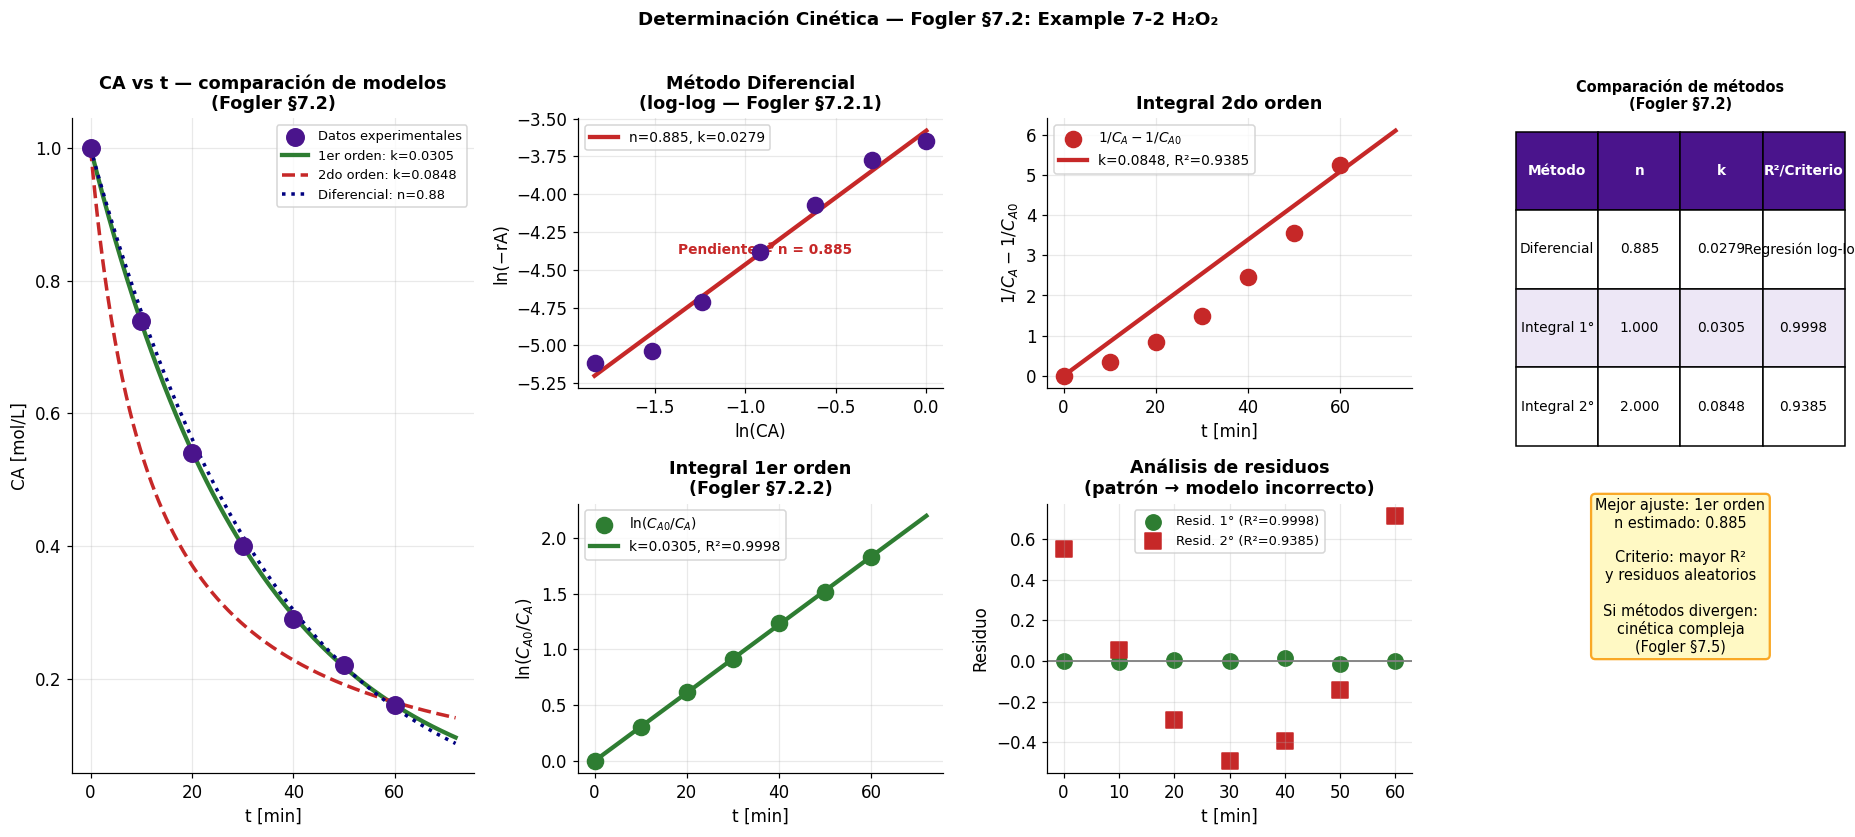

  Diferencial: n=0.885, k=0.02786 min⁻¹
  Integral 1°: k=0.03052, R²=0.99982
  Integral 2°: k=0.08477, R²=0.93849
  Mejor modelo: 1er orden


In [14]:
# Datos experimentales — Fogler Example 7-2 (p. 390)
t_exp  = np.array([0, 10, 20, 30, 40, 50, 60], dtype=float)
CA_exp = np.array([1.00, 0.74, 0.54, 0.40, 0.29, 0.22, 0.16])

# Método diferencial
dCdt    = np.gradient(CA_exp, t_exp)
rA_exp  = -dCdt
mask_d  = rA_exp > 0
p_diff  = np.polyfit(np.log(CA_exp[mask_d]), np.log(rA_exp[mask_d]), 1)
n_diff  = p_diff[0]; k_diff = np.exp(p_diff[1])

# Método integral — 1er orden
Y1 = np.log(CA_exp[0]/CA_exp)
p1 = np.polyfit(t_exp, Y1, 1); k1 = p1[0]
R2_1 = 1 - np.var(Y1-np.polyval(p1,t_exp))/np.var(Y1)

# Método integral — 2do orden
Y2 = 1/CA_exp - 1/CA_exp[0]
p2 = np.polyfit(t_exp, Y2, 1); k2 = p2[0]
R2_2 = 1 - np.var(Y2-np.polyval(p2,t_exp))/np.var(Y2)

t_fit = np.linspace(0, t_exp[-1]*1.2, 300)

fig = plt.figure(figsize=(17, 7.5))
gs  = fig.add_gridspec(2, 4, width_ratios=[2.2, 2, 2, 1.8])

# CA vs t con modelos
ax0 = fig.add_subplot(gs[:, 0])
ax0.scatter(t_exp, CA_exp, color='#4A148C', s=130, zorder=8,
            label='Datos experimentales')
ax0.plot(t_fit, CA_exp[0]*np.exp(-k1*t_fit), '#2E7D32', lw=2.8,
         label=f'1er orden: k={k1:.4f}')
ax0.plot(t_fit, CA_exp[0]/(1+k2*CA_exp[0]*t_fit), '#C62828', lw=2.3, ls='--',
         label=f'2do orden: k={k2:.4f}')
def batch_nd(y, t_): return [-k_diff*max(y[0],0)**n_diff]
sol_n = odeint(batch_nd, [CA_exp[0]], t_fit)
ax0.plot(t_fit, sol_n[:,0], 'navy', lw=2.3, ls=':',
         label=f'Diferencial: n={n_diff:.2f}')
ax0.set_xlabel('t [min]'); ax0.set_ylabel('CA [mol/L]')
ax0.set_title('CA vs t — comparación de modelos\n(Fogler §7.2)')
ax0.legend(fontsize=8.5)

# Método diferencial (log-log)
ax1 = fig.add_subplot(gs[0, 1])
xl = np.linspace(np.log(CA_exp[mask_d]).min(),
                 np.log(CA_exp[mask_d]).max(), 100)
ax1.scatter(np.log(CA_exp[mask_d]), np.log(rA_exp[mask_d]),
            color='#4A148C', s=110, zorder=8)
ax1.plot(xl, np.polyval(p_diff, xl), '#C62828', lw=2.8,
         label=f'n={n_diff:.3f}, k={k_diff:.4f}')
ax1.annotate(f'Pendiente = n = {n_diff:.3f}',
             xy=(xl[55], np.polyval(p_diff, xl[55])),
             xytext=(xl[25], np.polyval(p_diff, xl[25])+0.4),
             fontsize=9, color='#C62828', fontweight='bold',
             arrowprops=dict(arrowstyle='->', color='#C62828'))
ax1.set_xlabel('ln(CA)'); ax1.set_ylabel('ln(−rA)')
ax1.set_title('Método Diferencial\n(log-log — Fogler §7.2.1)')
ax1.legend(fontsize=9)

# Integral 1er orden
ax2 = fig.add_subplot(gs[1, 1])
ax2.scatter(t_exp, Y1, color='#2E7D32', s=110, zorder=8,
            label=r'$\ln(C_{A0}/C_A)$')
ax2.plot(t_fit, k1*t_fit, '#2E7D32', lw=2.8,
         label=f'k={k1:.4f}, R²={R2_1:.4f}')
ax2.set_xlabel('t [min]'); ax2.set_ylabel(r'$\ln(C_{A0}/C_A)$')
ax2.set_title('Integral 1er orden\n(Fogler §7.2.2)'); ax2.legend(fontsize=9)

# Integral 2do orden
ax3 = fig.add_subplot(gs[0, 2])
ax3.scatter(t_exp, Y2, color='#C62828', s=110, zorder=8,
            label=r'$1/C_A-1/C_{A0}$')
ax3.plot(t_fit, k2*t_fit, '#C62828', lw=2.8,
         label=f'k={k2:.4f}, R²={R2_2:.4f}')
ax3.set_xlabel('t [min]'); ax3.set_ylabel(r'$1/C_A-1/C_{A0}$')
ax3.set_title('Integral 2do orden'); ax3.legend(fontsize=9)

# Residuos
ax4 = fig.add_subplot(gs[1, 2])
res1 = Y1 - np.polyval(p1, t_exp)
res2 = Y2 - np.polyval(p2, t_exp)
ax4.scatter(t_exp, res1, color='#2E7D32', s=100,
            label=f'Resid. 1° (R²={R2_1:.4f})')
ax4.scatter(t_exp, res2, color='#C62828', s=100, marker='s',
            label=f'Resid. 2° (R²={R2_2:.4f})')
ax4.axhline(0, color='gray', lw=1.2)
ax4.set_xlabel('t [min]'); ax4.set_ylabel('Residuo')
ax4.set_title('Análisis de residuos\n(patrón → modelo incorrecto)')
ax4.legend(fontsize=8.5)

# Tabla comparativa
ax5 = fig.add_subplot(gs[:, 3]); ax5.axis('off')
mejor = '1er orden' if R2_1 > R2_2 else '2do orden'
rows = [['Método', 'n', 'k', 'R²/Criterio'],
        ['Diferencial', f'{n_diff:.3f}', f'{k_diff:.4f}', 'Regresión log-log'],
        ['Integral 1°', '1.000',         f'{k1:.4f}',     f'{R2_1:.4f}'],
        ['Integral 2°', '2.000',         f'{k2:.4f}',     f'{R2_2:.4f}']]
tbl = ax5.table(cellText=rows[1:], colLabels=rows[0],
                cellLoc='center', loc='upper center', bbox=[0, 0.50, 1, 0.48])
tbl.auto_set_font_size(False); tbl.set_fontsize(9)
for j in range(4):
    tbl[0,j].set_facecolor('#4A148C')
    tbl[0,j].set_text_props(color='white', fontweight='bold')
for i in range(1, 4):
    bg = '#EDE7F6' if i%2==0 else 'white'
    for j in range(4): tbl[i,j].set_facecolor(bg)
ax5.text(0.5, 0.42,
         f'Mejor ajuste: {mejor}\n'
         f'n estimado: {n_diff:.3f}\n\n'
         'Criterio: mayor R²\ny residuos aleatorios\n\n'
         'Si métodos divergen:\ncinética compleja\n(Fogler §7.5)',
         ha='center', va='top', transform=ax5.transAxes, fontsize=9.5,
         bbox=dict(boxstyle='round', facecolor='#FFF9C4',
                   edgecolor='#F9A825', lw=1.5))
ax5.set_title('Comparación de métodos\n(Fogler §7.2)', fontweight='bold', fontsize=9.5)

plt.suptitle('Determinación Cinética — Fogler §7.2: Example 7-2 H₂O₂',
             fontsize=12, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()
print(f'  Diferencial: n={n_diff:.3f}, k={k_diff:.5f} min⁻¹')
print(f'  Integral 1°: k={k1:.5f}, R²={R2_1:.5f}')
print(f'  Integral 2°: k={k2:.5f}, R²={R2_2:.5f}')
print(f'  Mejor modelo: {mejor}')


---
# 4. Batch No Isotérmico — simulación y análisis de seguridad (Fogler §9.1-§9.2)

## 4.1 Sistema de ODEs acopladas

$$\frac{dX}{dt} = k(T)(1-X) \qquad \text{[balance de masa, 1er orden]}$$

$$\frac{dT}{dt} = \frac{UA(T_a-T) + (-\Delta H_{rx})\cdot(-r_A)\cdot V}{\sum N_i C_{p,i}} \qquad \text{[balance de energía]}$$

## 4.2 Análisis del acoplamiento no lineal

El acoplamiento es **exponencial** y genera el fenómeno de *runaway*:

1. Reacción exotérmica → $T$ sube.
2. Mayor $T$ → $k(T) = k_0 e^{-E_a/RT}$ sube exponencialmente.
3. Mayor $k$ → mayor velocidad → más calor.
4. Si el enfriamiento no puede seguir este ritmo → **runaway térmico**.

La sensibilidad a la temperatura inicial $T_0$ es otra manifestación de este acoplamiento: una diferencia de 5-10°C en $T_0$ puede llevar a trayectorias completamente diferentes.

## 4.3 Tiempo de máxima velocidad $t_{mr}$ — diseño de seguridad

El **TMR (Time to Maximum Rate)** satisface $d(-r_A)/dt = 0$. Es el tiempo al que el sistema es más peligroso porque:

- **Antes del TMR**: $-r_A$ crece → sistema se acelera → falla de enfriamiento es crítica.
- **Después del TMR**: $-r_A$ decrece → sistema se desacelera → falla menos peligrosa.

**Estándar industrial STOEMP** (Safe Time of Emergency Measurements and Procedures):

$$t_{STEM} < t_{mr,\text{adiabático}} / 4$$

Es decir, los sistemas de intervención de emergencia deben actuar en menos de un cuarto del TMR adiabático.

## 4.4 Ejercicio de análisis de riesgo

Con los sliders del widget siguiente, responda:

1. ¿Cuánto UA mínimo necesita para mantener $T_{max} < 380$ K si $\Delta H = -120$ kJ/mol?
2. Si $UA$ cae a cero en $t = t_{mr}/2$, ¿qué ocurre con la temperatura?
3. ¿Cómo cambia $t_{mr}$ al subir $T_0$ en 10 K?


In [17]:
from ipywidgets import interact, FloatSlider # Added interact and FloatSlider import
R_b=8.314e-3; k0_b=7.08e10; Ea_b0=75.36
CA0_b=2.0; CpA_b=0.167; V_b=5.0

def plot_batch_ni(dH_b=-80., UA_b=0., Ta_b=320., T0_b=300.,
                  Ea_b=75.36, t_max=120.):
    NA0 = CA0_b * V_b
    def k_b(T): return k0_b*np.exp(-Ea_b/(R_b*T))
    def odes(y, t_):
        X_, T_ = y
        X_ = max(0, min(X_, 0.9999)); T_ = max(T_, 250)
        CA = CA0_b*(1-X_); rA = k_b(T_)*CA
        dX = rA/CA0_b
        dT = (UA_b*(Ta_b-T_)/1000 + (-dH_b)*rA*V_b) / (NA0*CpA_b)
        return [dX, dT]

    t_ = np.linspace(0, t_max, 4000)

    # Tres condiciones iniciales
    ci_data = [
        (T0_b,   '#0D47A1', '-',  f'T₀={T0_b:.0f}K (nominal)'),
        (T0_b+8, '#C62828', '--', f'T₀+8K={T0_b+8:.0f}K'),
        (T0_b-8, '#2E7D32', ':',  f'T₀−8K={T0_b-8:.0f}K'),
    ]
    sols = [(odeint(odes, [0., Ti], t_), c, ls, lbl)
            for Ti, c, ls, lbl in ci_data]

    # TMR (condición nominal)
    sol0, _, _, _ = sols[0]
    X0  = np.clip(sol0[:,0], 0, 1); T0a = sol0[:,1]
    rA_arr = np.array([k_b(T0a[i])*CA0_b*(1-X0[i]) for i in range(len(t_))])
    idx_mr = np.argmax(rA_arr)
    t_mr   = t_[idx_mr]; T_mr = T0a[idx_mr]

    dTad = (-dH_b)/(CpA_b*1000)*CA0_b

    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    fig.suptitle(f'Batch No Isotérmico — ΔH={dH_b}kJ/mol, '
                 f'UA={UA_b:.0f}W/K, Eₐ={Ea_b:.1f}kJ/mol\n'
                 f'ΔT_ad={dTad:.1f}K | T_max_ad={T0_b+dTad:.1f}K',
                 fontsize=12, fontweight='bold', y=1.01)

    # X(t)
    for sol, c, ls, lbl in sols:
        X_ = np.clip(sol[:,0], 0, 1)
        axes[0,0].plot(t_, X_, color=c, ls=ls, lw=2.3, label=lbl)
    axes[0,0].axhline(0.90, color='gold', ls='--', lw=1.8, label='X=0.90')
    axes[0,0].axvline(t_mr, color='#6A1B9A', ls=':', lw=2.0,
                      label=f't_mr={t_mr:.1f}min')
    axes[0,0].set_xlabel('t [min]'); axes[0,0].set_ylabel('$X_A$')
    axes[0,0].set_title('Conversión vs tiempo\n(sensibilidad a T₀ inicial)')
    axes[0,0].legend(fontsize=8.5); axes[0,0].set_ylim(0, 1.05)

    # T(t)
    for sol, c, ls, lbl in sols:
        T_ = sol[:,1]
        axes[0,1].plot(t_, T_, color=c, ls=ls, lw=2.3, label=lbl)
    axes[0,1].axhline(T0_b, color='gray', ls='--', lw=1.5, label=f'T₀={T0_b:.0f}K')
    axes[0,1].axhline(T0_b+dTad, color='#C62828', ls=':', lw=1.3,
                      label=f'T_max_ad={T0_b+dTad:.0f}K', alpha=0.8)
    if UA_b > 0:
        axes[0,1].axhline(Ta_b, color='orange', ls='-.', lw=1.5,
                          label=f'Tₐ={Ta_b:.0f}K')
    axes[0,1].axvline(t_mr, color='#6A1B9A', ls=':', lw=2.0,
                      label=f't_mr={t_mr:.1f}min')
    axes[0,1].set_xlabel('t [min]'); axes[0,1].set_ylabel('T [K]')
    axes[0,1].set_title('Perfil de temperatura\n(análisis de seguridad térmica)')
    axes[0,1].legend(fontsize=8.5)

    # Ensure T-axis always has a visible range for T(t) plot
    all_T_values = np.concatenate([s[0][:,1] for s in sols])
    min_T_val = np.min(all_T_values)
    max_T_val = np.max(all_T_values)

    # Check if the range is effectively zero or NaN
    if np.isnan(min_T_val) or np.isnan(max_T_val) or min_T_val == max_T_val:
        # Provide a default reasonable range centered around T0_b
        center_T = T0_b
        axes[0,1].set_ylim(center_T - 5, center_T + 5)
        axes[1,0].set_xlim(center_T - 5, center_T + 5)
    else:
        # Provide a buffer of at least 1K or 10% of the range, centered
        T_buffer_y = max(1.0, (max_T_val - min_T_val) * 0.1)
        axes[0,1].set_ylim(min_T_val - T_buffer_y, max_T_val + T_buffer_y)

        # Ensure T-axis (x-axis here) always has a visible range for X-T plot
        T_buffer_x = max(1.0, (max_T_val - min_T_val) * 0.1) # Same buffer for x-axis
        axes[1,0].set_xlim(min_T_val - T_buffer_x, max_T_val + T_buffer_x)

    # Espacio de fase X-T
    if UA_b < 1e-2:
        Xr = np.linspace(0, 1, 80)
        axes[1,0].plot(T0_b+dTad*Xr, Xr, 'orange', ls='--', lw=2.0,
                       alpha=0.85, label=f'Línea adiabática ΔT={dTad:.1f}K')
    for sol, c, ls, lbl in sols:
        X_ = np.clip(sol[:,0], 0, 1); T_ = sol[:,1]
        axes[1,0].plot(T_, X_, color=c, ls=ls, lw=2.3, label=lbl)
    axes[1,0].scatter([T0_b],     [0],       color='#2E7D32', s=150,
                      zorder=9, edgecolors='black', label='Inicio')
    axes[1,0].scatter([T0a[-1]],  [X0[-1]],  color='#C62828', s=150,
                      zorder=9, edgecolors='black',
                      label=f'Final X={X0[-1]:.3f}')
    axes[1,0].set_xlabel('T [K]'); axes[1,0].set_ylabel('$X_A$')
    axes[1,0].set_title('Espacio de fase X-T\n(trayectoria dinámica)')
    axes[1,0].legend(fontsize=8.5)


    # Velocidad -r_A con TMR
    axes[1,1].plot(t_, rA_arr, '#6A1B9A', lw=3.0)
    axes[1,1].axvline(t_mr, color='#C62828', ls='--', lw=2.5,
                      label=f't_mr = {t_mr:.1f} min')
    axes[1,1].scatter([t_mr], [rA_arr[idx_mr]], s=220, color='#C62828',
                       zorder=9, edgecolors='black', lw=2)
    axes[1,1].fill_between(t_[:idx_mr+1], 0, rA_arr[:idx_mr+1],
                            alpha=0.22, color='#C62828',
                            label='FASE CRÍTICA: aceleración\n'
                                  '(falla de enfriamiento = runaway)')
    axes[1,1].fill_between(t_[idx_mr:], 0, rA_arr[idx_mr:],
                            alpha=0.15, color='#2E7D32',
                            label='FASE SEGURA: desaceleración')
    axes[1,1].set_xlabel('t [min]')
    axes[1,1].set_ylabel('$-r_A$ [mol/(L·min)]')
    axes[1,1].set_title(f'Velocidad de reacción\n'
                         f't_mr = {t_mr:.1f} min  (Fogler §9.2)')
    axes[1,1].legend(fontsize=8.5)

    plt.tight_layout()
    plt.savefig('/home/claude/reactores/fig_nb4_noiso.png',
                dpi=110, bbox_inches='tight')
    plt.show()
    T_max = T0a.max()
    crit = ('ALTA — runaway posible' if (UA_b<1 and dTad>150)
            else 'MODERADA' if dTad>50 else 'BAJA')
    print(f'  T_max = {T_max:.2f}K ({T_max-273.15:.2f}°C)')
    print(f'  ΔT_ad = {dTad:.1f}K → T_max_ad = {T0_b+dTad:.1f}K')
    print(f'  t_mr  = {t_mr:.2f} min ({t_mr/60:.4f} h)')
    print(f'  X en t_mr = {X0[idx_mr]:.4f}')
    print(f'  X_final   = {X0[-1]:.4f}')
    print(f'  Criticidad: {crit}')

interact(plot_batch_ni,
    dH_b =FloatSlider(value=-80., min=-250., max=-5.,  step=5.,
                      description='ΔH [kJ/mol]',  style={'description_width':'150px'}),
    UA_b =FloatSlider(value=0.,   min=0.,    max=800., step=20.,
                      description='UA [W/K]',      style={'description_width':'150px'}),
    Ta_b =FloatSlider(value=320., min=280.,  max=380., step=2.,
                      description='Tₐ [K]',        style={'description_width':'150px'}),
    T0_b =FloatSlider(value=300., min=275.,  max=340., step=2.,
                      description='T₀ [K]',        style={'description_width':'150px'}),
    Ea_b =FloatSlider(value=75.36,min=20.,   max=150., step=2.,
                      description='Eₐ [kJ/mol]',   style={'description_width':'150px'}),
    t_max=FloatSlider(value=120., min=10.,   max=600., step=10.,
                      description='t_max [min]',   style={'description_width':'150px'})
);

interactive(children=(FloatSlider(value=-80.0, description='ΔH [kJ/mol]', max=-5.0, min=-250.0, step=5.0, styl…

---
# 5. Comparación CSTR / PFR / Batch — Fogler §5.3 y §4.2

## 5.1 Relación fundamental de tamaños

Para la misma cinética, $C_{A0}$ y conversión $X_A$:

$$t_\text{batch} = \tau_\text{PFR} = C_{A0}\int_0^X\frac{dX}{-r_A} \;\;\mathbf{<}\;\; \tau_\text{CSTR} = \frac{C_{A0}X}{-r_A(X_\text{sal})}$$

La razón $\tau_\text{CSTR}/\tau_\text{PFR}$ es exactamente el cociente del rectángulo sobre el área bajo la curva en el Diagrama de Levenspiel.

## 5.2 Tabla de selección de reactor

| Criterio | CSTR | PFR | Batch |
|----------|------|-----|-------|
| Volumen ($n>0$) | Mayor | Menor | ≈ PFR |
| Control térmico | ★★★★★ | ★★★ | ★★★★ |
| Sólidos suspensión | ★★★★★ | ★ | ★★★★★ |
| Cinética autocatalítica | ★★★★★ | ★★ | ★★★ |
| Escala (t/año) | > 50 kt | > 10 kt | < 10 kt |
| Flexibilidad prod. | Baja | Baja | Muy alta |
| Inversión capita | Media | Alta | Baja |


In [18]:
def comparar_reactores(n_cmp=1.0, k_cmp=0.5, CA0_cmp=2.0):
    X_range = np.linspace(0.001, 0.999, 700)
    CA  = CA0_cmp*(1-X_range)
    rA  = k_cmp*CA**n_cmp
    Y   = CA0_cmp/rA
    tau_CSTR = Y*X_range
    tau_PFR  = cumulative_trapezoid(Y, X_range, initial=0)
    ratio    = np.where(tau_PFR>1e-12, tau_CSTR/tau_PFR, 1.)

    fig, axes = plt.subplots(1, 3, figsize=(17, 5.5))
    fig.suptitle(f'Comparación CSTR / PFR / Batch — Fogler §5.3\n'
                 f'n={n_cmp:.2f}, k={k_cmp:.2f} min⁻¹, CA0={CA0_cmp}mol/L',
                 fontsize=12, fontweight='bold', y=1.01)

    # τ vs X
    axes[0].plot(X_range, tau_CSTR, '#C62828', lw=3, label='CSTR')
    axes[0].plot(X_range, tau_PFR,  '#0D47A1', lw=3, label='PFR = Batch')
    axes[0].fill_between(X_range, tau_PFR, tau_CSTR,
                         alpha=0.15, color='#C62828', label='Exceso CSTR')
    for xv, col in zip([0.5, 0.8, 0.9, 0.95],
                       ['#1976D2','#C62828','#2E7D32','#7B1FA2']):
        axes[0].axvline(xv, color=col, ls=':', lw=1.4, alpha=0.7)
    axes[0].set_xlabel('Conversión $X_A$')
    axes[0].set_ylabel('Tiempo espacial τ [min]')
    axes[0].set_title('τ vs X_A para CSTR y PFR\n(PFR=Batch siempre menor)')
    axes[0].legend(fontsize=9)

    # Razón V_CSTR/V_PFR vs X
    axes[1].plot(X_range, ratio, '#0D47A1', lw=3)
    axes[1].axhline(1.0, color='gray', lw=1.2)
    axes[1].fill_between(X_range, 1, ratio, alpha=0.15, color='#C62828',
                         label='Exceso de volumen CSTR')
    for xv, col in zip([0.5, 0.8, 0.9],
                       ['#1976D2','#C62828','#2E7D32']):
        rv = np.interp(xv, X_range, ratio)
        axes[1].axvline(xv, color=col, ls=':', lw=1.3, alpha=0.7)
        axes[1].text(xv+0.01, rv+0.05, f'{rv:.2f}×', fontsize=8.5,
                     color=col, fontweight='bold')
    axes[1].set_xlabel('Conversión $X_A$')
    axes[1].set_ylabel('$\\tau_\mathrm{CSTR} / \\tau_\mathrm{PFR}$')
    axes[1].set_title('Razón de tamaños vs X\n(crece con X y con orden n)')
    axes[1].legend(fontsize=9)

    # Levenspiel comparativo
    X_p = np.linspace(0.001, 0.998, 800)
    CA_p = CA0_cmp*(1-X_p)
    Yn = CA0_cmp/(k_cmp*CA_p**n_cmp)
    Yn_clip = np.minimum(Yn, Yn[X_p<0.98].max()*3)

    X_des = 0.80
    idx_d = np.argmin(np.abs(X_p - X_des))
    Y_d = Yn_clip[idx_d]

    axes[2].plot(X_p, Yn_clip, '#0D47A1', lw=3, label='Curva cinética')
    axes[2].fill_between([0, X_des], [0,0], [Y_d, Y_d],
                         alpha=0.30, color='#C62828',
                         label=f'CSTR: τ={Y_d*X_des:.2f}min')
    axes[2].plot([0, X_des, X_des], [Y_d, Y_d, 0], '#C62828', ls='--', lw=2)
    mask = X_p <= X_des
    axes[2].fill_between(X_p[mask], 0, Yn_clip[mask],
                         alpha=0.22, color='#0D47A1',
                         label=f'PFR=Batch: τ={np.trapz(Yn[mask],X_p[mask]):.2f}min')
    axes[2].set_xlabel('$X_A$')
    axes[2].set_ylabel(r'$C_{A0}/(-r_A)$ [min]')
    axes[2].set_title(f'Diagrama de Levenspiel (X={X_des})\nRectángulo CSTR > Área PFR')
    axes[2].legend(fontsize=9)
    axes[2].set_xlim(0, 1)

    plt.tight_layout(); plt.show()
    for xv in [0.5, 0.8, 0.9, 0.95]:
        rv = np.interp(xv, X_range, ratio)
        print(f'  X={xv:.2f}: CSTR necesita {rv:.2f}× el volumen del PFR')

interact(comparar_reactores,
    n_cmp  =FloatSlider(value=1.0, min=0.25, max=3.5, step=0.25, description='Orden n'),
    k_cmp  =FloatSlider(value=0.5, min=0.01, max=3.0, step=0.05, description='k [min⁻¹]'),
    CA0_cmp=FloatSlider(value=2.0, min=0.5,  max=5.0, step=0.1,  description='CA0 [mol/L]')
);


interactive(children=(FloatSlider(value=1.0, description='Orden n', max=3.5, min=0.25, step=0.25), FloatSlider…

---
# 🎓 Resumen y cierre del programa

## Conceptos clave de este módulo

| Concepto | Resultado central |
|----------|------------------|
| Ec. diseño batch | $t = C_{A0}\int_0^X dX/(-r_A)$ — equivalente al PFR con $t\leftrightarrow\tau$ |
| Productividad óptima | Existe $X^*$ que maximiza $\mathcal{P}$, no necesariamente $X=1$ |
| Método diferencial | $n$ y $k$ de la pendiente e intercepto del gráfico log-log $\ln(-r_A)$ vs $\ln C_A$ |
| Método integral | Verificación del orden por linealización; $R^2$ como criterio de selección |
| Batch no isotérmico | ODEs acopladas $dX/dt$ y $dT/dt$; feedback exponencial por Arrhenius |
| TMR | Tiempo al máximo de velocidad — referencia de seguridad para sistemas de emergencia |
| Comparación CSTR/PFR/Batch | $\tau_\text{PFR} = t_\text{batch} < \tau_\text{CSTR}$ para todo $n>0$ |

## Cierre del programa de Reactores Homogéneos

Los cuatro notebooks cubren la totalidad del contenido de **reactores homogéneos** del programa 740484:

| Notebook | Reactor | Condición | Fogler |
|----------|---------|-----------|--------|
| 1 | CSTR | Isotérmico | Cap. 2, 3, 5, 13 |
| 2 | CSTR | No isotérmico | Cap. 8, 9 |
| 3 | PFR | Isotérmico y no isotérmico | Cap. 2, 5, 6, 8 |
| 4 | Batch | Isotérmico, cinética, no isotérmico | Cap. 4, 7, 9 |

**Próxima etapa del curso** (reactores heterogéneos):
- Difusión y reacción en catalizadores porosos — factor de efectividad η.
- Reactor de lecho fijo (PBR) — modelo seudo-homogéneo, ecuación de Ergun.
- Reactores gas-líquido — teoría de la doble película, factor de realce.

---
*Notebook 4 — Programa 740484 · Maestría Ingeniería Química · Universidad del Valle · 2024*
